In [1]:
# ============================================================
# 污水处理厂出水水质预测项目
# Notebook 03: Baseline Models
#
# 目的：
# 1. 建立简单的 time-series forecasting baseline
# 2. 使用 chronological split，避免未来信息泄漏
# 3. 评估 Persistence Baseline
# 4. 评估 Linear Trend Baseline
# 5. 同时评估整体表现和 High-Change Period 表现
#
# Baseline 1: Persistence
# 假设两小时后的水质与当前水质相同：
#
#     y_hat(t+1) = y(t)
#
# Baseline 2: Linear Trend
# 假设最近两个时间点的变化趋势继续：
#
#     y_hat(t+1) = y(t) + [y(t) - y(t-1)]
#
# 这些 baseline 将作为后续 Ridge、Random Forest、
# XGBoost 和 LSTM 模型必须比较的最低参考标准。
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("Libraries imported successfully.")

C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Libraries imported successfully.


In [2]:
# ============================================================
# 1. 读取 COD、TN、TP 数据
#
# 三个数据集：
# COD -> eff 代表 Effluent COD
# TN  -> eff 代表 Effluent TN
# TP  -> eff 代表 Effluent TP
# ============================================================

DATA_DIR = Path("../data")

cod = pd.read_csv(DATA_DIR / "cod.csv")
tn = pd.read_csv(DATA_DIR / "tn.csv")
tp = pd.read_csv(DATA_DIR / "tp.csv")

datasets = {
    "COD": cod,
    "TN": tn,
    "TP": tp
}

for df in datasets.values():
    df["sampling_time"] = pd.to_datetime(df["sampling_time"])
    df.sort_values("sampling_time", inplace=True)
    df.reset_index(drop=True, inplace=True)

for name, df in datasets.items():
    print(
        f"{name}: "
        f"{len(df):,} observations | "
        f"{df['sampling_time'].min()} -> "
        f"{df['sampling_time'].max()}"
    )

COD: 6,289 observations | 2022-07-07 01:00:00 -> 2023-12-13 01:00:00
TN: 6,289 observations | 2022-07-07 01:00:00 -> 2023-12-13 01:00:00
TP: 6,289 observations | 2022-07-07 01:00:00 -> 2023-12-13 01:00:00


In [3]:
# ============================================================
# 2. Chronological Train/Test Split
#
# Time-series data 不能随机打乱后再切分。
#
# 这里按照时间顺序：
#
# 前 95% -> Train / Model Development
# 后 5%  -> Final Test
#
# Baseline 不需要训练，
# 但后续所有模型都必须使用同一个 final test period，
# 才能进行公平比较。
# ============================================================

TEST_RATIO = 0.05

splits = {}

for name, df in datasets.items():

    split_index = int(len(df) * (1 - TEST_RATIO))

    train_df = df.iloc[:split_index].copy()
    test_df = df.iloc[split_index:].copy()

    splits[name] = {
        "train": train_df,
        "test": test_df,
        "split_index": split_index
    }

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("Train observations:", len(train_df))
    print(
        "Train period:",
        train_df["sampling_time"].min(),
        "->",
        train_df["sampling_time"].max()
    )

    print("\nTest observations:", len(test_df))
    print(
        "Test period:",
        test_df["sampling_time"].min(),
        "->",
        test_df["sampling_time"].max()
    )


COD
Train observations: 5974
Train period: 2022-07-07 01:00:00 -> 2023-11-16 19:00:00

Test observations: 315
Test period: 2023-11-16 21:00:00 -> 2023-12-13 01:00:00

TN
Train observations: 5974
Train period: 2022-07-07 01:00:00 -> 2023-11-16 19:00:00

Test observations: 315
Test period: 2023-11-16 21:00:00 -> 2023-12-13 01:00:00

TP
Train observations: 5974
Train period: 2022-07-07 01:00:00 -> 2023-11-16 19:00:00

Test observations: 315
Test period: 2023-11-16 21:00:00 -> 2023-12-13 01:00:00


In [4]:
# ============================================================
# 2. Chronological Train/Test Split
#
# Time-series data 不能随机打乱后再切分。
#
# 这里按照时间顺序：
#
# 前 95% -> Train / Model Development
# 后 5%  -> Final Test
#
# Baseline 不需要训练，
# 但后续所有模型都必须使用同一个 final test period，
# 才能进行公平比较。
# ============================================================

TEST_RATIO = 0.05

splits = {}

for name, df in datasets.items():

    split_index = int(len(df) * (1 - TEST_RATIO))

    train_df = df.iloc[:split_index].copy()
    test_df = df.iloc[split_index:].copy()

    splits[name] = {
        "train": train_df,
        "test": test_df,
        "split_index": split_index
    }

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("Train observations:", len(train_df))
    print(
        "Train period:",
        train_df["sampling_time"].min(),
        "->",
        train_df["sampling_time"].max()
    )

    print("\nTest observations:", len(test_df))
    print(
        "Test period:",
        test_df["sampling_time"].min(),
        "->",
        test_df["sampling_time"].max()
    )


COD
Train observations: 5974
Train period: 2022-07-07 01:00:00 -> 2023-11-16 19:00:00

Test observations: 315
Test period: 2023-11-16 21:00:00 -> 2023-12-13 01:00:00

TN
Train observations: 5974
Train period: 2022-07-07 01:00:00 -> 2023-11-16 19:00:00

Test observations: 315
Test period: 2023-11-16 21:00:00 -> 2023-12-13 01:00:00

TP
Train observations: 5974
Train period: 2022-07-07 01:00:00 -> 2023-11-16 19:00:00

Test observations: 315
Test period: 2023-11-16 21:00:00 -> 2023-12-13 01:00:00


In [5]:
# ============================================================
# 3. Persistence Baseline
#
# Persistence 的逻辑非常简单：
#
# 当前实际值 = 对下一时间点的预测值
#
# 例如：
#
# 09:00 COD = 9.5
#
# 那么预测：
#
# 11:00 COD = 9.5
#
# 因为数据每两小时记录一次，
# 所以这是一个 2-hour-ahead forecast。
# ============================================================

def persistence_forecast(series):
    """
    使用当前值预测下一个时间点。
    """

    y_true = series.iloc[1:].to_numpy()
    y_pred = series.iloc[:-1].to_numpy()

    return y_true, y_pred

In [6]:
# ============================================================
# 4. Evaluation Metrics
#
# 使用以下指标：
#
# MAE:
# 平均绝对误差，越小越好。
#
# RMSE:
# 对较大的预测错误更加敏感，越小越好。
#
# MAPE:
# 平均百分比误差，越小越好。
#
# R²:
# 衡量模型解释 target variation 的程度，越接近 1 越好。
#
# Within 5%:
# 有多少预测与真实值的相对误差不超过 5%。
#
# Within 10%:
# 有多少预测与真实值的相对误差不超过 10%。
# ============================================================

def evaluate_forecast(y_true, y_pred):

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = (
        mean_absolute_percentage_error(
            y_true,
            y_pred
        ) * 100
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    relative_error = (
        np.abs(y_true - y_pred)
        / np.abs(y_true)
    )

    within_5 = (
        relative_error <= 0.05
    ).mean() * 100

    within_10 = (
        relative_error <= 0.10
    ).mean() * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "R²": r2,
        "Within ±5% (%)": within_5,
        "Within ±10% (%)": within_10
    }

In [7]:
# ============================================================
# 5. Evaluate Persistence Baseline
#
# 为了预测 test set 的第一个 observation，
# 使用 train set 最后一个已知 eff。
#
# 因此将：
#
# train 最后一行 + test set
#
# 连接起来，再生成 persistence prediction。
# ============================================================

persistence_results = []

persistence_predictions = {}

for name in ["COD", "TN", "TP"]:

    train_df = splits[name]["train"]
    test_df = splits[name]["test"]

    evaluation_series = pd.concat([
        train_df["eff"].iloc[-1:],
        test_df["eff"]
    ])

    y_true, y_pred = persistence_forecast(
        evaluation_series
    )

    metrics = evaluate_forecast(
        y_true,
        y_pred
    )

    metrics["Target"] = name
    metrics["Model"] = "Persistence"

    persistence_results.append(metrics)

    persistence_predictions[name] = {
        "time": test_df["sampling_time"].to_numpy(),
        "y_true": y_true,
        "y_pred": y_pred
    }

persistence_results = pd.DataFrame(
    persistence_results
)

persistence_results[
    [
        "Target",
        "Model",
        "MAE",
        "RMSE",
        "MAPE (%)",
        "R²",
        "Within ±5% (%)",
        "Within ±10% (%)"
    ]
]

,Target,Model,MAE,RMSE,MAPE (%),R²,Within ±5% (%),Within ±10% (%)
0,COD,Persistence,0.070991,0.097197,0.938603,0.967161,99.365079,100.000000
1,TN,Persistence,0.122696,0.155972,1.086989,0.972546,99.682540,100.000000
2,TP,Persistence,0.014946,0.021671,3.868972,0.919784,73.650794,91.746032


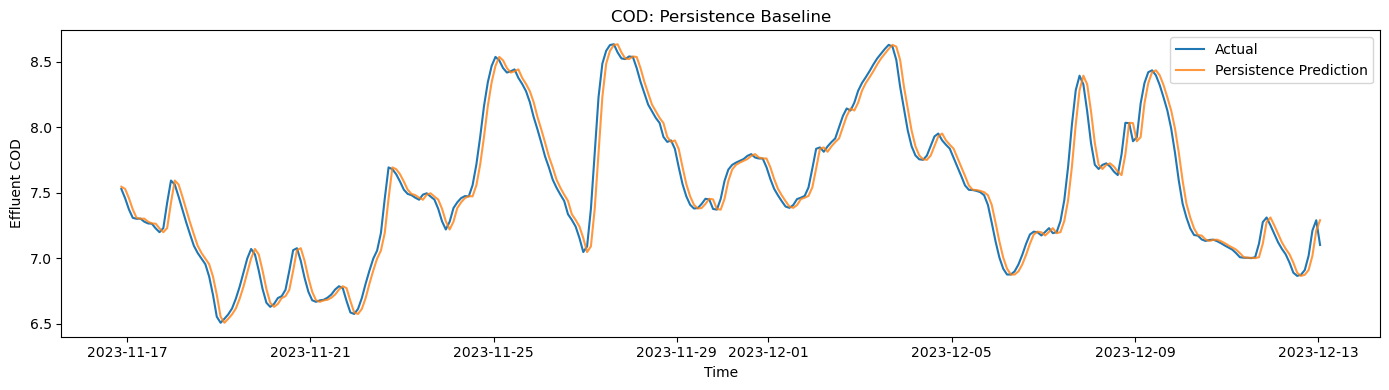

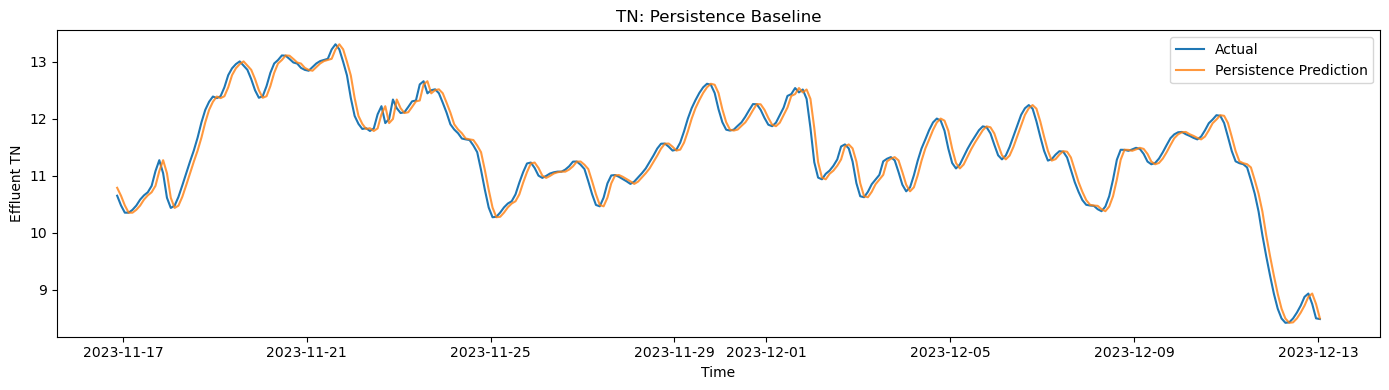

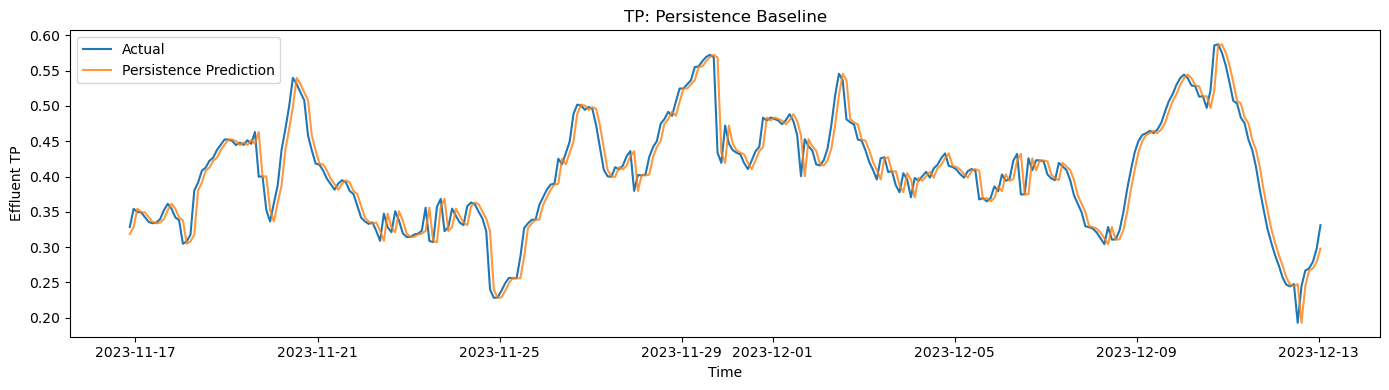

In [8]:
# ============================================================
# 6. Persistence: Actual vs Predicted Over Time
#
# 如果 persistence 很强，
# predicted line 应该与 actual line 非常接近。
# ============================================================

for name in ["COD", "TN", "TP"]:

    result = persistence_predictions[name]

    plt.figure(figsize=(14, 4))

    plt.plot(
        result["time"],
        result["y_true"],
        label="Actual"
    )

    plt.plot(
        result["time"],
        result["y_pred"],
        label="Persistence Prediction",
        alpha=0.8
    )

    plt.title(
        f"{name}: Persistence Baseline"
    )

    plt.xlabel("Time")
    plt.ylabel(f"Effluent {name}")

    plt.legend()

    plt.tight_layout()
    plt.show()

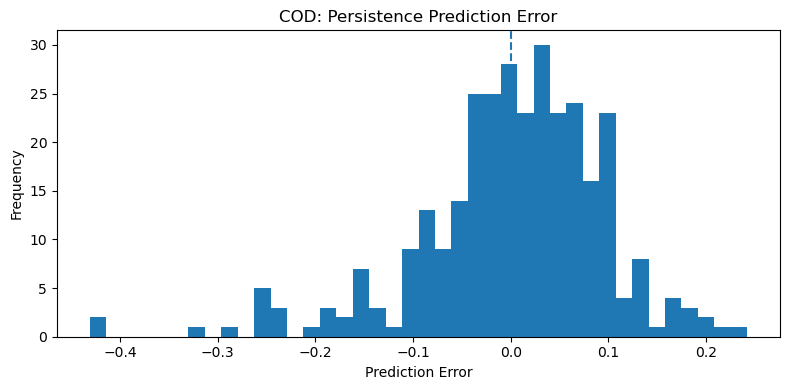

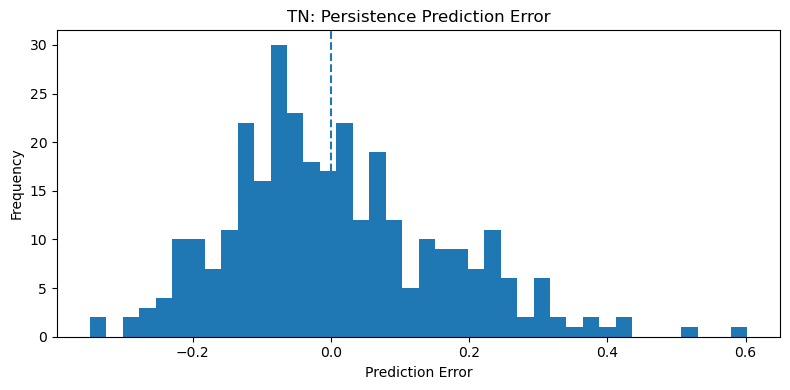

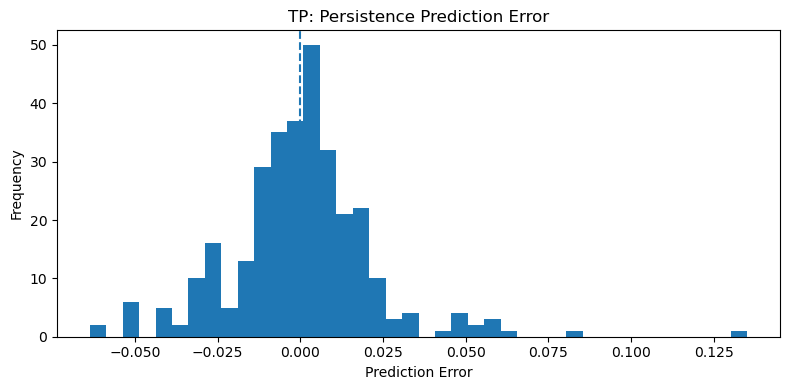

In [9]:
# ============================================================
# 7. Persistence Error Distribution
#
# Error = Prediction - Actual
#
# 如果 error 大量集中在 0 附近，
# 说明 persistence 在大多数时间表现很好。
# ============================================================

for name in ["COD", "TN", "TP"]:

    result = persistence_predictions[name]

    error = (
        result["y_pred"]
        - result["y_true"]
    )

    plt.figure(figsize=(8, 4))

    plt.hist(
        error,
        bins=40
    )

    plt.axvline(
        0,
        linestyle="--"
    )

    plt.title(
        f"{name}: Persistence Prediction Error"
    )

    plt.xlabel("Prediction Error")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [10]:
# ============================================================
# 8. Linear Trend Baseline
#
# 假设最近一次变化趋势会继续。
#
# Prediction:
#
# y_hat(t+1)
# = y(t) + [y(t) - y(t-1)]
#
# 例如：
#
# 09:00 = 9.0
# 11:00 = 9.2
#
# 最近变化 = +0.2
#
# 预测：
# 13:00 = 9.4
# ============================================================

def trend_forecast(series):

    values = series.to_numpy()

    y_true = values[2:]

    y_pred = (
        values[1:-1]
        + (
            values[1:-1]
            - values[:-2]
        )
    )

    return y_true, y_pred

In [11]:
# ============================================================
# 9. Evaluate Linear Trend Baseline
#
# Trend prediction 需要前两个 observations，
# 所以使用：
#
# train 最后两行 + test set
#
# 从而预测完整的 final test period。
# ============================================================

trend_results = []

trend_predictions = {}

for name in ["COD", "TN", "TP"]:

    train_df = splits[name]["train"]
    test_df = splits[name]["test"]

    evaluation_series = pd.concat([
        train_df["eff"].iloc[-2:],
        test_df["eff"]
    ])

    y_true, y_pred = trend_forecast(
        evaluation_series
    )

    metrics = evaluate_forecast(
        y_true,
        y_pred
    )

    metrics["Target"] = name
    metrics["Model"] = "Linear Trend"

    trend_results.append(metrics)

    trend_predictions[name] = {
        "time": test_df["sampling_time"].to_numpy(),
        "y_true": y_true,
        "y_pred": y_pred
    }

trend_results = pd.DataFrame(
    trend_results
)

trend_results[
    [
        "Target",
        "Model",
        "MAE",
        "RMSE",
        "MAPE (%)",
        "R²",
        "Within ±5% (%)",
        "Within ±10% (%)"
    ]
]

,Target,Model,MAE,RMSE,MAPE (%),R²,Within ±5% (%),Within ±10% (%)
0,COD,Linear Trend,0.043943,0.063625,0.581662,0.985928,100.00000,100.000000
1,TN,Linear Trend,0.080348,0.109879,0.705864,0.986375,100.00000,100.000000
2,TP,Linear Trend,0.018373,0.028004,4.815044,0.866054,70.47619,85.396825


In [12]:
# ============================================================
# 10. Baseline Model Comparison
#
# 比较：
#
# 1. Persistence
# 2. Linear Trend
#
# 所有模型使用相同的 final test period。
# ============================================================

baseline_results = pd.concat([
    persistence_results,
    trend_results
], ignore_index=True)

baseline_results = baseline_results[
    [
        "Target",
        "Model",
        "MAE",
        "RMSE",
        "MAPE (%)",
        "R²",
        "Within ±5% (%)",
        "Within ±10% (%)"
    ]
]

baseline_results.sort_values(
    ["Target", "MAE"]
)

,Target,Model,MAE,RMSE,MAPE (%),R²,Within ±5% (%),Within ±10% (%)
3,COD,Linear Trend,0.043943,0.063625,0.581662,0.985928,100.000000,100.000000
0,COD,Persistence,0.070991,0.097197,0.938603,0.967161,99.365079,100.000000
4,TN,Linear Trend,0.080348,0.109879,0.705864,0.986375,100.000000,100.000000
1,TN,Persistence,0.122696,0.155972,1.086989,0.972546,99.682540,100.000000
2,TP,Persistence,0.014946,0.021671,3.868972,0.919784,73.650794,91.746032
5,TP,Linear Trend,0.018373,0.028004,4.815044,0.866054,70.476190,85.396825


In [13]:
# ============================================================
# 10. Baseline Model Comparison
#
# 比较：
#
# 1. Persistence
# 2. Linear Trend
#
# 所有模型使用相同的 final test period。
# ============================================================

baseline_results = pd.concat([
    persistence_results,
    trend_results
], ignore_index=True)

baseline_results = baseline_results[
    [
        "Target",
        "Model",
        "MAE",
        "RMSE",
        "MAPE (%)",
        "R²",
        "Within ±5% (%)",
        "Within ±10% (%)"
    ]
]

baseline_results.sort_values(
    ["Target", "MAE"]
)

,Target,Model,MAE,RMSE,MAPE (%),R²,Within ±5% (%),Within ±10% (%)
3,COD,Linear Trend,0.043943,0.063625,0.581662,0.985928,100.000000,100.000000
0,COD,Persistence,0.070991,0.097197,0.938603,0.967161,99.365079,100.000000
4,TN,Linear Trend,0.080348,0.109879,0.705864,0.986375,100.000000,100.000000
1,TN,Persistence,0.122696,0.155972,1.086989,0.972546,99.682540,100.000000
2,TP,Persistence,0.014946,0.021671,3.868972,0.919784,73.650794,91.746032
5,TP,Linear Trend,0.018373,0.028004,4.815044,0.866054,70.476190,85.396825


In [14]:
# ============================================================
# 12. Define High-Change Threshold from Training Data
#
# 为了避免使用 test information，
# High-Change threshold 只根据 training data 计算。
#
# 定义：
#
# |y(t) - y(t-1)| > training 95th percentile
#
# 则认为该 observation 属于 High-Change Period。
# ============================================================

high_change_thresholds = {}

for name in ["COD", "TN", "TP"]:

    train_df = splits[name]["train"]

    train_abs_change = (
        train_df["eff"]
        .diff()
        .abs()
        .dropna()
    )

    threshold = train_abs_change.quantile(
        0.95
    )

    high_change_thresholds[name] = threshold

    print(
        f"{name}: "
        f"High-Change Threshold = "
        f"{threshold:.6f}"
    )

COD: High-Change Threshold = 0.276073
TN: High-Change Threshold = 0.348126
TP: High-Change Threshold = 0.056913


In [15]:
# ============================================================
# 13. Persistence Performance During High-Change Periods
#
# 研究：
#
# Persistence 在整体 test set 上可能表现很好，
# 但当水质发生明显变化时是否仍然准确？
#
# High-Change:
#
# |Actual(t) - Actual(t-1)|
# > training 95th percentile
# ============================================================

high_change_results = []

for name in ["COD", "TN", "TP"]:

    result = persistence_predictions[name]

    y_true = result["y_true"]
    y_pred = result["y_pred"]

    threshold = high_change_thresholds[name]

    # 对 persistence 来说，
    # y_pred 就是上一时间点的真实值。
    actual_change = np.abs(
        y_true - y_pred
    )

    high_change_mask = (
        actual_change > threshold
    )

    high_y_true = y_true[
        high_change_mask
    ]

    high_y_pred = y_pred[
        high_change_mask
    ]

    metrics = evaluate_forecast(
        high_y_true,
        high_y_pred
    )

    metrics["Target"] = name
    metrics["Model"] = "Persistence"
    metrics["Period"] = "High Change"
    metrics["Observations"] = high_change_mask.sum()

    high_change_results.append(
        metrics
    )

high_change_results = pd.DataFrame(
    high_change_results
)

high_change_results[
    [
        "Target",
        "Observations",
        "MAE",
        "RMSE",
        "MAPE (%)",
        "R²",
        "Within ±5% (%)",
        "Within ±10% (%)"
    ]
]

,Target,Observations,MAE,RMSE,MAPE (%),R²,Within ±5% (%),Within ±10% (%)
0,COD,4,0.365437,0.370757,4.637479,-0.378422,50.0,100.0
1,TN,8,0.431365,0.438609,3.939629,0.741548,87.5,100.0
2,TP,7,0.074677,0.079020,19.792412,0.298472,0.0,0.0


In [16]:
# ============================================================
# 14. Overall vs High-Change Performance
#
# 比较 Persistence：
#
# 整体 test performance
#          VS
# High-Change performance
#
# 目的：
# 判断 persistence 的高性能是否主要来自
# 大量稳定的 operating periods。
# ============================================================

comparison_rows = []

for name in ["COD", "TN", "TP"]:

    overall = persistence_results[
        persistence_results["Target"] == name
    ].iloc[0]

    high = high_change_results[
        high_change_results["Target"] == name
    ].iloc[0]

    comparison_rows.append({
        "Target": name,

        "Overall MAE":
            overall["MAE"],

        "High-Change MAE":
            high["MAE"],

        "Overall MAPE (%)":
            overall["MAPE (%)"],

        "High-Change MAPE (%)":
            high["MAPE (%)"],

        "Overall Within ±5% (%)":
            overall["Within ±5% (%)"],

        "High-Change Within ±5% (%)":
            high["Within ±5% (%)"]
    })

overall_vs_high_change = pd.DataFrame(
    comparison_rows
)

overall_vs_high_change

,Target,Overall MAE,High-Change MAE,Overall MAPE (%),High-Change MAPE (%),Overall Within ±5% (%),High-Change Within ±5% (%)
0,COD,0.070991,0.365437,0.938603,4.637479,99.365079,50.0
1,TN,0.122696,0.431365,1.086989,3.939629,99.682540,87.5
2,TP,0.014946,0.074677,3.868972,19.792412,73.650794,0.0


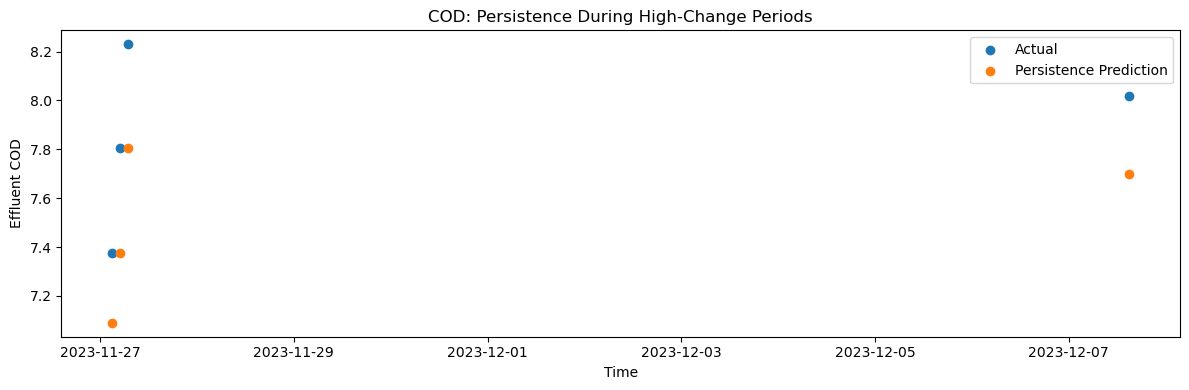

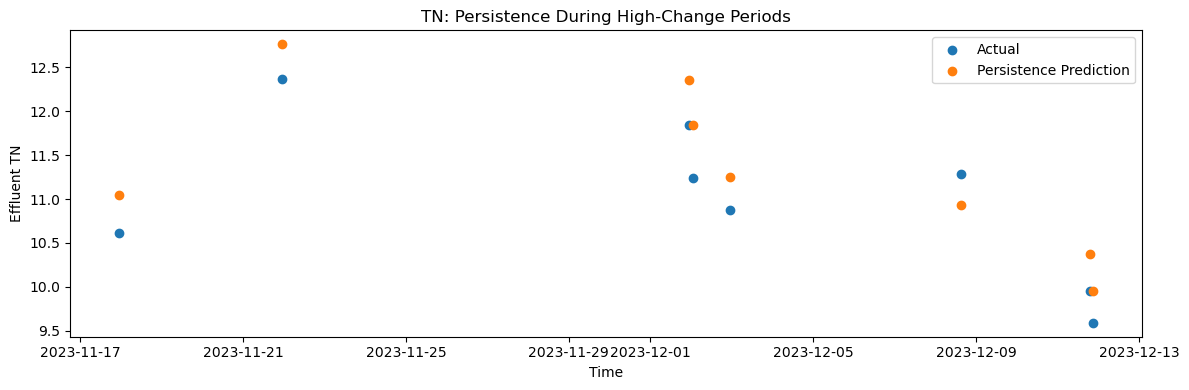

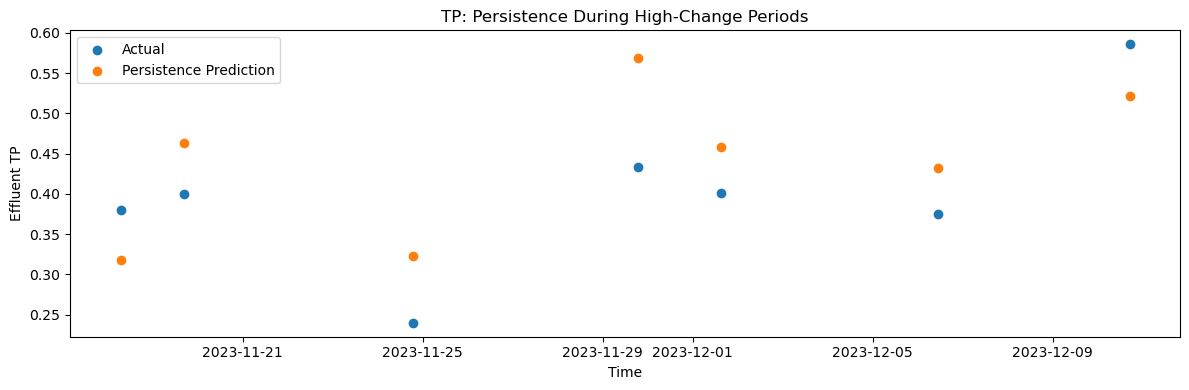

In [17]:
# ============================================================
# 15. Visualize High-Change Prediction Errors
#
# 只显示 test period 中被定义为
# High-Change 的 observations。
#
# 观察 persistence 在水质快速变化时
# 是否出现明显的滞后。
# ============================================================

for name in ["COD", "TN", "TP"]:

    result = persistence_predictions[name]

    y_true = result["y_true"]
    y_pred = result["y_pred"]
    time = result["time"]

    threshold = high_change_thresholds[name]

    actual_change = np.abs(
        y_true - y_pred
    )

    high_change_mask = (
        actual_change > threshold
    )

    plt.figure(figsize=(12, 4))

    plt.scatter(
        time[high_change_mask],
        y_true[high_change_mask],
        label="Actual"
    )

    plt.scatter(
        time[high_change_mask],
        y_pred[high_change_mask],
        label="Persistence Prediction"
    )

    plt.title(
        f"{name}: Persistence During High-Change Periods"
    )

    plt.xlabel("Time")
    plt.ylabel(f"Effluent {name}")

    plt.legend()

    plt.tight_layout()
    plt.show()

In [18]:
# ============================================================
# 16. Save Baseline Results
#
# 将 baseline evaluation 保存到 results/，
# 后续 ML 和 LSTM 可以直接与这些结果比较。
# ============================================================

RESULTS_DIR = Path("../results")

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

baseline_results.to_csv(
    RESULTS_DIR / "baseline_results.csv",
    index=False
)

overall_vs_high_change.to_csv(
    RESULTS_DIR / "persistence_high_change_results.csv",
    index=False
)

print("Results saved to:")
print(RESULTS_DIR / "baseline_results.csv")
print(RESULTS_DIR / "persistence_high_change_results.csv")

Results saved to:
..\results\baseline_results.csv
..\results\persistence_high_change_results.csv


In [19]:
# ============================================================
# 17. Baseline Summary
#
# 自动总结每个 target：
#
# - 哪个 baseline 的 MAE 最低
# - Persistence 的 overall performance
# - Persistence 在 high-change periods 的表现
# ============================================================

for name in ["COD", "TN", "TP"]:

    subset = baseline_results[
        baseline_results["Target"] == name
    ]

    best_model = subset.loc[
        subset["MAE"].idxmin()
    ]

    persistence = subset[
        subset["Model"] == "Persistence"
    ].iloc[0]

    high_change = high_change_results[
        high_change_results["Target"] == name
    ].iloc[0]

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print(
        f"Best baseline: "
        f"{best_model['Model']}"
    )

    print(
        f"Best baseline MAE: "
        f"{best_model['MAE']:.4f}"
    )

    print(
        f"Persistence R²: "
        f"{persistence['R²']:.4f}"
    )

    print(
        f"Persistence MAPE: "
        f"{persistence['MAPE (%)']:.2f}%"
    )

    print(
        f"Persistence predictions within ±5%: "
        f"{persistence['Within ±5% (%)']:.2f}%"
    )

    print(
        f"High-change observations: "
        f"{int(high_change['Observations'])}"
    )

    print(
        f"Persistence high-change MAE: "
        f"{high_change['MAE']:.4f}"
    )

    print(
        f"Persistence high-change within ±5%: "
        f"{high_change['Within ±5% (%)']:.2f}%"
    )


COD
Best baseline: Linear Trend
Best baseline MAE: 0.0439
Persistence R²: 0.9672
Persistence MAPE: 0.94%
Persistence predictions within ±5%: 99.37%
High-change observations: 4
Persistence high-change MAE: 0.3654
Persistence high-change within ±5%: 50.00%

TN
Best baseline: Linear Trend
Best baseline MAE: 0.0803
Persistence R²: 0.9725
Persistence MAPE: 1.09%
Persistence predictions within ±5%: 99.68%
High-change observations: 8
Persistence high-change MAE: 0.4314
Persistence high-change within ±5%: 87.50%

TP
Best baseline: Persistence
Best baseline MAE: 0.0149
Persistence R²: 0.9198
Persistence MAPE: 3.87%
Persistence predictions within ±5%: 73.65%
High-change observations: 7
Persistence high-change MAE: 0.0747
Persistence high-change within ±5%: 0.00%
